In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

df=pd.read_csv('synthetic_beverage_sales_data.csv')

In [2]:
df


,Order_ID,Customer_ID,Customer_Type,Product,Category,Unit_Price,Quantity,Discount,Total_Price,Region,Order_Date
0,ORD1,CUS1496,B2B,Vio Wasser,Water,1.66,53,0.10,79.18,Baden-Württemberg,2023-08-23
1,ORD1,CUS1496,B2B,Evian,Water,1.56,90,0.10,126.36,Baden-Württemberg,2023-08-23
2,ORD1,CUS1496,B2B,Sprite,Soft Drinks,1.17,73,0.05,81.14,Baden-Württemberg,2023-08-23
3,ORD1,CUS1496,B2B,Rauch Multivitamin,Juices,3.22,59,0.10,170.98,Baden-Württemberg,2023-08-23
4,ORD1,CUS1496,B2B,Gerolsteiner,Water,0.87,35,0.10,27.40,Baden-Württemberg,2023-08-23
...,...,...,...,...,...,...,...,...,...,...,...
8999905,ORD2999999,CUS7080,B2C,Schwip Schwap,Soft Drinks,1.27,2,0.00,2.54,Sachsen,2023-07-03
8999906,ORD2999999,CUS7080,B2C,San Pellegrino,Water,0.91,15,0.00,13.65,Sachsen,2023-07-03
8999907,ORD3000000,CUS6551,B2B,Red Bull,Soft Drinks,2.94,64,0.10,169.34,Sachsen-Anhalt,2022-04-09
8999908,ORD3000000,CUS6551,B2B,Passion Fruit Juice,Juices,4.04,79,0.10,287.24,Sachsen-Anhalt,2022-04-09


In [3]:
df['Order_Date'] = pd.to_datetime(df['Order_Date'])
df['YearMonth']=df['Order_Date'].dt.to_period('M')

In [4]:
dfb2b=df[df['Customer_Type']=='B2B']

In [5]:
monthly_share = (
    df.groupby(['YearMonth','Customer_Type'])['Total_Price']
      .sum()
      .groupby(level=0)
      .apply(lambda x: x / x.sum())
)
monthly_share

YearMonth  YearMonth  Customer_Type
2021-01    2021-01    B2B              0.769430
                      B2C              0.230570
2021-02    2021-02    B2B              0.764901
                      B2C              0.235099
2021-03    2021-03    B2B              0.769956
                                         ...   
2023-10    2023-10    B2C              0.231188
2023-11    2023-11    B2B              0.766370
                      B2C              0.233630
2023-12    2023-12    B2B              0.768815
                      B2C              0.231185
Name: Total_Price, Length: 72, dtype: float64

In [6]:
# Agrupamos los datos por nivel de descuento de los clientes B2B
# Esto nos permite comparar el comportamiento de compra para cada descuento
volume_analysis= (
    dfb2b.groupby('Discount')
      .agg( 
          # Número de pedidos únicos por nivel de descuento
          Orders=('Order_ID', 'nunique'),
          
          # Cantidad media de unidades compradas por pedido
          Avg_Quantity=('Quantity', 'mean'),
          
          # Volumen total de unidades vendidas con cada descuento
          Total_Quantity=('Quantity', 'sum')
      )
      # Convertimos el índice en columna para facilitar el análisis
      .reset_index()
      
      # Ordenamos por nivel de descuento para una lectura más clara
      .sort_values('Discount')
)

volume_analysis


,Discount,Orders,Avg_Quantity,Total_Quantity
0,0.05,818956,33.925298,48815077
1,0.10,804217,62.051699,85916100
2,0.15,325690,71.255036,27149380


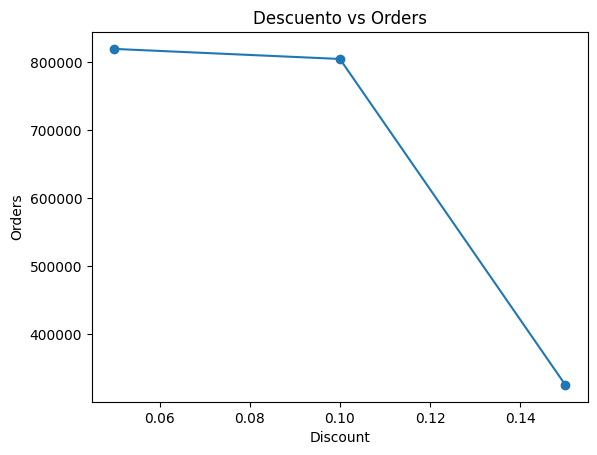

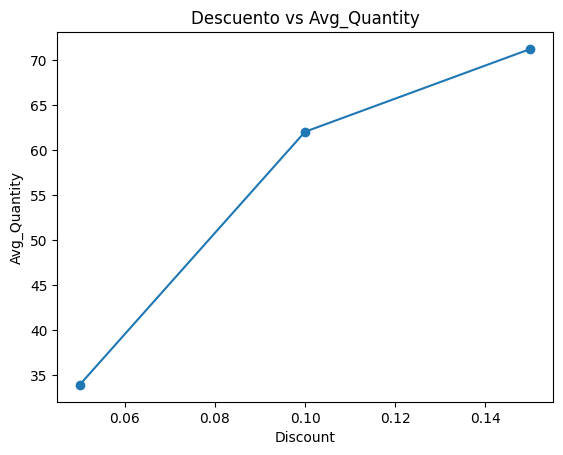

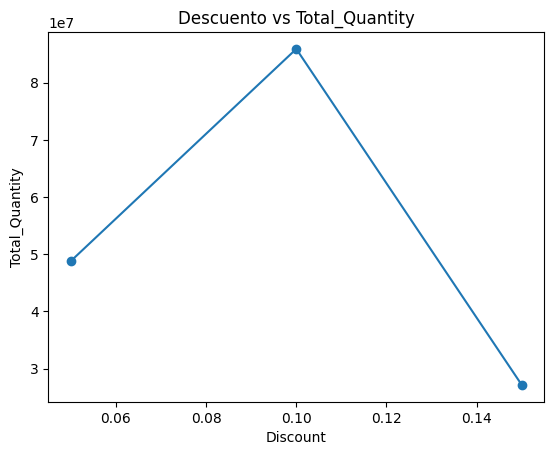

In [7]:
# Recorremos las métricas de volumen para generar un gráfico por cada una
for variable in volume_analysis.columns:
    
    # Excluimos la columna Discount, ya que se utiliza como eje X
    if variable == 'Discount':
        continue

    plt.figure()
    
    # Representamos la evolución de cada métrica en función del descuento
    plt.plot(
        volume_analysis['Discount'],
        volume_analysis[variable],
        marker='o'
    )
    
    plt.xlabel('Discount')
    plt.ylabel(variable)
    plt.title(f'Descuento vs {variable}')
    plt.show()


In [8]:
# Agrupamos los datos por nivel de descuento de los clientes B2B
# El objetivo es analizar cómo varían los ingresos según el porcentaje aplicado
revenue_analysis = (
    dfb2b.groupby('Discount')
      .agg(
          # Ingreso promedio por pedido (permite analizar efecto en ticket medio)
          Avg_Revenue=('Total_Price', 'mean'),
          
          # Ingreso total agregado por nivel de descuento
          Total_Revenue=('Total_Price', 'sum'),
          
          # Total de unidades vendidas con cada descuento
          Total_Quantity=('Quantity', 'sum')
      )
      .reset_index()
)

# Calculamos el ingreso medio por unidad vendida
# Esto nos permite evaluar si el descuento erosiona el valor económico unitario
revenue_analysis['Revenue_per_Unit'] = (
    revenue_analysis['Total_Revenue'] /
    revenue_analysis['Total_Quantity'])
revenue_analysis

,Discount,Avg_Revenue,Total_Revenue,Total_Quantity,Revenue_per_Unit
0,0.05,171.044878,2.461163e+08,48815077,5.041809
1,0.10,356.039056,4.929678e+08,85916100,5.737781
2,0.15,426.583455,1.625355e+08,27149380,5.986713


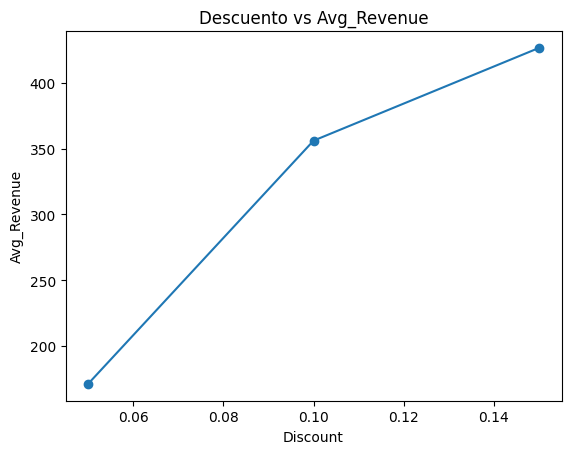

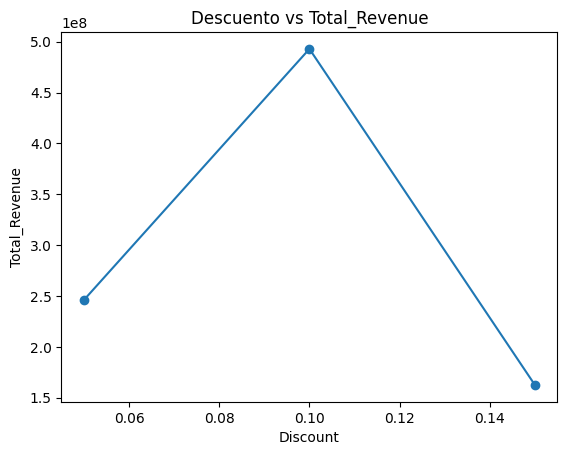

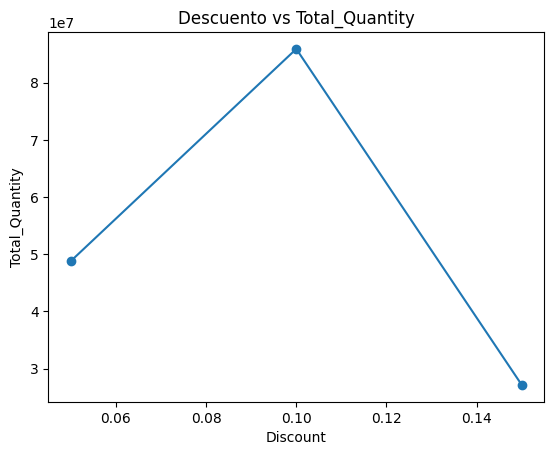

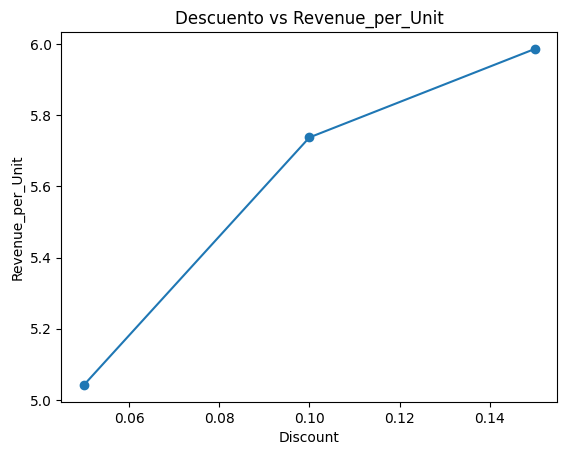

In [9]:
# Generamos un gráfico por cada métrica de ingreso
for variable in revenue_analysis.columns:
    
    # Excluimos Discount porque será el eje X
    if variable == 'Discount':
        continue

    plt.figure()
    
    # Representamos la evolución de cada métrica en función del descuento
    plt.plot(
        revenue_analysis['Discount'],
        revenue_analysis[variable],
        marker='o'
    )
    
    plt.xlabel('Discount')
    plt.ylabel(variable)
    plt.title(f'Descuento vs {variable}')
    plt.show()


In [10]:
dfb2b['Revenue_per_Unit_line'] = (
    dfb2b['Total_Price'] /
    dfb2b['Quantity']
)
dfb2b.groupby('Discount')['Revenue_per_Unit_line'].mean()

Discount
0.05    4.676833
0.10    5.442902
0.15    5.736509
Name: Revenue_per_Unit_line, dtype: float64

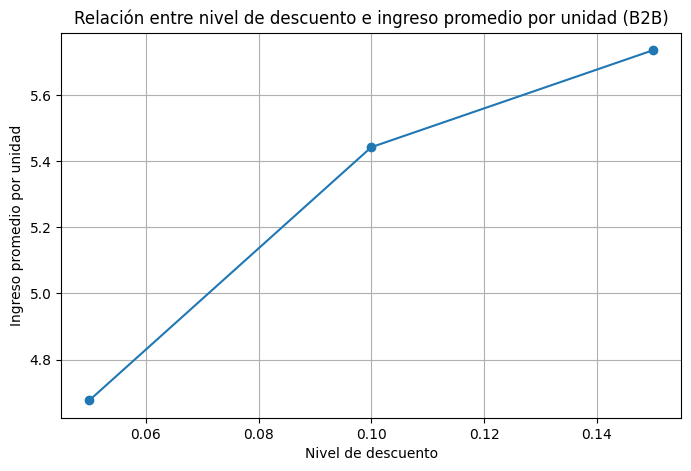

In [11]:

# Cálculo del ingreso efectivo por unidad a nivel de línea de pedido.
# Se divide el ingreso total de cada línea entre la cantidad vendida
# para obtener el precio unitario realmente pagado tras el descuento.
dfb2b['Revenue_per_Unit_line'] = (
    dfb2b['Total_Price'] /
    dfb2b['Quantity']
)

# Agrupación por nivel de descuento.
# Se calcula el ingreso promedio por unidad para cada nivel,
# lo que permite analizar cómo varía el precio efectivo medio
# cuando cambia la intensidad del descuento.
revenue_per_unit_by_discount = (
    dfb2b
    .groupby('Discount')['Revenue_per_Unit_line']
    .mean()
    .reset_index()
    .sort_values('Discount')
)

# Representación gráfica de la relación entre descuento
# e ingreso promedio por unidad.
# El objetivo es visualizar la tendencia y comprobar si
# existe erosión mecánica del precio unitario.
plt.figure(figsize=(8,5))

plt.plot(
    revenue_per_unit_by_discount['Discount'],
    revenue_per_unit_by_discount['Revenue_per_Unit_line'],
    marker='o'
)

plt.xlabel('Nivel de descuento')
plt.ylabel('Ingreso promedio por unidad')
plt.title('Relación entre nivel de descuento e ingreso promedio por unidad (B2B)')
plt.grid(True)

plt.show()


In [12]:
dfb2b.groupby(['Category','Discount']).agg(
    Total_Revenue=('Total_Price','sum'),
    Total_Quantity=('Quantity','sum')
)

Total_Revenue  Total_Quantity
Category            Discount                               
Alcoholic Beverages 0.05       1.888948e+08        12196635
                    0.10       3.824704e+08        21507358
                    0.15       1.265231e+08         6797731
Juices              0.05       2.884130e+07        12197033
                    0.10       5.513034e+07        21468429
                    0.15       1.789905e+07         6783066
Soft Drinks         0.05       1.819978e+07        12221460
                    0.10       3.482844e+07        21442374
                    0.15       1.132227e+07         6768704
Water               0.05       1.018039e+07        12199949
                    0.10       2.053862e+07        21497939
                    0.15       6.791094e+06         6799879

In [13]:
price_analysis = (
    dfb2b.groupby('Discount')
    .apply(lambda x: (x['Unit_Price'] * x['Quantity']).sum() / x['Quantity'].sum())
    .reset_index(name='Weighted_Avg_Base_Price')
)
price_analysis


,Discount,Weighted_Avg_Base_Price
0,0.05,5.307171
1,0.10,6.375311
2,0.15,7.043193


In [14]:
# --------------------------------------------
# 1. Cálculo del precio base ponderado por categoría y descuento
# --------------------------------------------

# Primero se crea una columna auxiliar que representa el valor base total
# por línea de pedido (precio unitario antes de descuento × cantidad vendida).
# Esto permite posteriormente calcular el promedio ponderado.
dfb2b['Base_Value'] = dfb2b['Unit_Price'] * dfb2b['Quantity']

# Se agrupan los datos por categoría y nivel de descuento.
# Para cada grupo se calcula:
# - la suma del valor base total
# - la suma de unidades vendidas
price_by_cat_discount = (
    dfb2b
    .groupby(['Category', 'Discount'])
    .agg(
        Total_Base_Value=('Base_Value', 'sum'),
        Total_Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

# Se calcula el precio base promedio ponderado.
# La ponderación por cantidad evita que líneas con bajo volumen
# distorsionen el precio promedio.
price_by_cat_discount['Weighted_Avg_Base_Price'] = (
    price_by_cat_discount['Total_Base_Value'] /
    price_by_cat_discount['Total_Quantity']
)

# Se eliminan las columnas auxiliares para dejar la tabla final limpia.
price_by_cat_discount = price_by_cat_discount.drop(
    columns=['Total_Base_Value', 'Total_Quantity']
)


# --------------------------------------------
# 2. Cálculo del precio efectivo ponderado
# --------------------------------------------

# Se calcula el precio efectivo por unidad a nivel de línea,
# dividiendo el ingreso total entre la cantidad vendida.
dfb2b['Effective_Price'] = (
    dfb2b['Total_Price'] / dfb2b['Quantity']
)

# Se crea una columna auxiliar con el valor efectivo total por línea
# (precio efectivo × cantidad).
dfb2b['Effective_Value'] = (
    dfb2b['Effective_Price'] * dfb2b['Quantity']
)

# Se agrupa nuevamente por categoría y descuento,
# calculando la suma del valor efectivo total
# y el total de unidades vendidas.
effective_by_cat_discount = (
    dfb2b
    .groupby(['Category', 'Discount'])
    .agg(
        Total_Effective_Value=('Effective_Value', 'sum'),
        Total_Quantity=('Quantity', 'sum')
    )
    .reset_index()
)

# Se calcula el precio efectivo promedio ponderado.
effective_by_cat_discount['Weighted_Avg_Effective_Price'] = (
    effective_by_cat_discount['Total_Effective_Value'] /
    effective_by_cat_discount['Total_Quantity']
)

# Se eliminan columnas auxiliares.
effective_by_cat_discount = effective_by_cat_discount.drop(
    columns=['Total_Effective_Value', 'Total_Quantity']
)


# --------------------------------------------
# 3. Comparación final
# --------------------------------------------

# Se combinan ambas tablas para poder comparar
# precio base promedio y precio efectivo promedio
# por categoría y nivel de descuento.
comparison = price_by_cat_discount.merge(
    effective_by_cat_discount,
    on=['Category', 'Discount']
)

comparison

,Category,Discount,Weighted_Avg_Base_Price,Weighted_Avg_Effective_Price
0,Alcoholic Beverages,0.05,16.302586,15.487454
1,Alcoholic Beverages,0.10,19.759147,17.783233
2,Alcoholic Beverages,0.15,21.897124,18.612554
3,Juices,0.05,2.489073,2.364616
4,Juices,0.10,2.853302,2.567973
5,Juices,0.15,3.104453,2.638785
6,Soft Drinks,0.05,1.567548,1.489166
7,Soft Drinks,0.10,1.804756,1.624281
8,Soft Drinks,0.15,1.967928,1.672738
9,Water,0.05,0.878385,0.834462


In [15]:
# Se define una función que recibe un grupo (sub-dataframe)
# y calcula el precio base promedio ponderado por cantidad.
def calcular_precio_base_ponderado(grupo):
    
    # Valor base total del grupo (precio unitario × cantidad)
    total_base_value = (grupo['Unit_Price'] * grupo['Quantity']).sum()
    
    # Total de unidades vendidas en el grupo
    total_quantity = grupo['Quantity'].sum()
    
    # Promedio ponderado
    return total_base_value / total_quantity

# Se aplica la función a cada combinación de categoría y descuento
price_by_cat_discount = (
    dfb2b
    .groupby(['Category', 'Discount'])
    .apply(calcular_precio_base_ponderado)
    .reset_index(name='Weighted_Avg_Base_Price')
)

# Primero se calcula el precio efectivo por unidad a nivel de línea
dfb2b['Effective_Price'] = (
    dfb2b['Total_Price'] / dfb2b['Quantity']
)

# Se define la función para el precio efectivo ponderado
def calcular_precio_efectivo_ponderado(grupo):
    
    # Valor efectivo total (precio efectivo × cantidad)
    total_effective_value = (grupo['Effective_Price'] * grupo['Quantity']).sum()
    
    # Total de unidades vendidas
    total_quantity = grupo['Quantity'].sum()
    
    # Promedio ponderado
    return total_effective_value / total_quantity


# Se aplica la función a cada grupo
effective_by_cat_discount = (
    dfb2b
    .groupby(['Category', 'Discount'])
    .apply(calcular_precio_efectivo_ponderado)
    .reset_index(name='Weighted_Avg_Effective_Price')
)

# Se combinan ambas métricas en una sola tabla
comparison = price_by_cat_discount.merge(
    effective_by_cat_discount,
    on=['Category', 'Discount']
)

comparison

,Category,Discount,Weighted_Avg_Base_Price,Weighted_Avg_Effective_Price
0,Alcoholic Beverages,0.05,16.302586,15.487454
1,Alcoholic Beverages,0.10,19.759147,17.783233
2,Alcoholic Beverages,0.15,21.897124,18.612554
3,Juices,0.05,2.489073,2.364616
4,Juices,0.10,2.853302,2.567973
5,Juices,0.15,3.104453,2.638785
6,Soft Drinks,0.05,1.567548,1.489166
7,Soft Drinks,0.10,1.804756,1.624281
8,Soft Drinks,0.15,1.967928,1.672738
9,Water,0.05,0.878385,0.834462


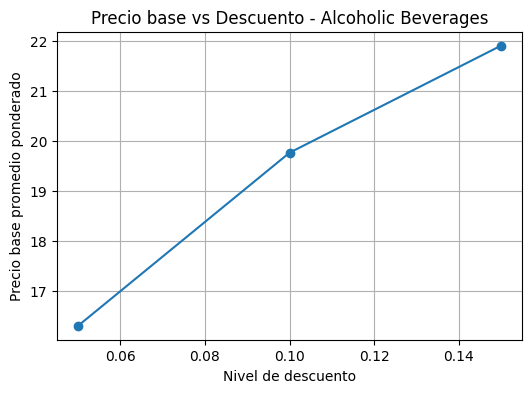

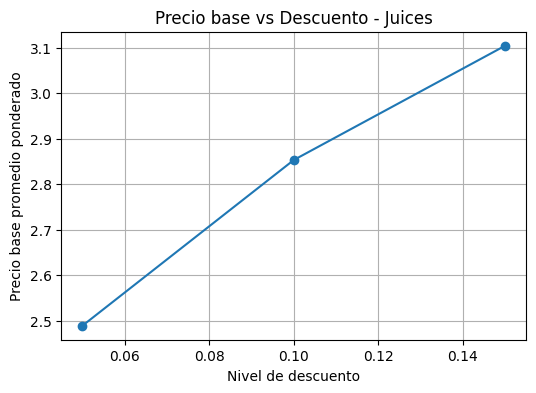

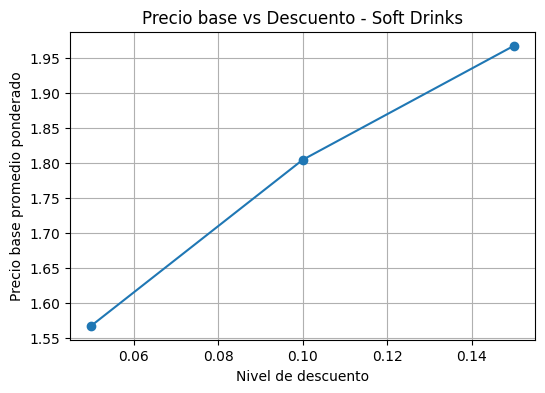

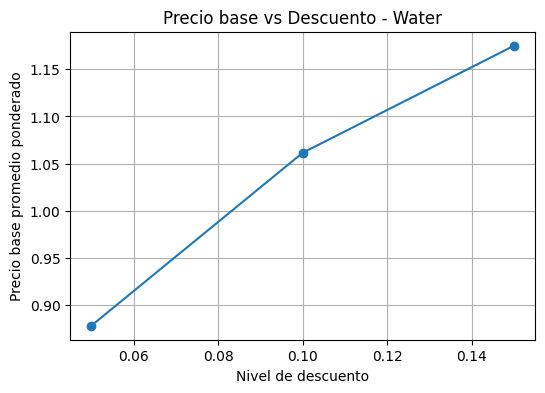

In [16]:

# Obtenemos las categorías únicas
categories = comparison['Category'].unique()

# Creamos un gráfico independiente por cada categoría
for cat in categories:
    
    subset = comparison[comparison['Category'] == cat]
    
    plt.figure(figsize=(6,4))
    
    plt.plot(
        subset['Discount'],
        subset['Weighted_Avg_Base_Price'],
        marker='o'
    )
    
    plt.xlabel('Nivel de descuento')
    plt.ylabel('Precio base promedio ponderado')
    plt.title(f'Precio base vs Descuento - {cat}')
    plt.grid(True)
    
    plt.show()

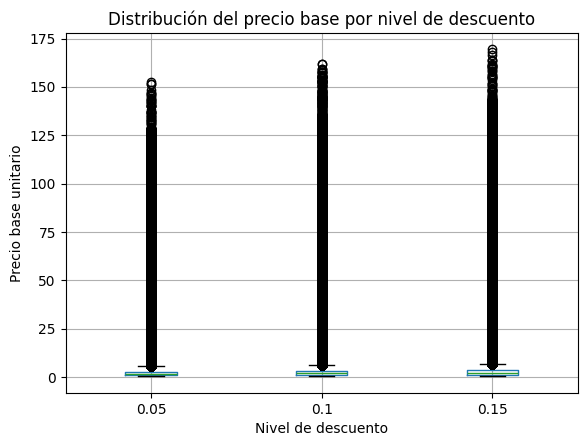

In [17]:


dfb2b.boxplot(column='Unit_Price', by='Discount')

plt.xlabel('Nivel de descuento')
plt.ylabel('Precio base unitario')
plt.title('Distribución del precio base por nivel de descuento')
plt.suptitle('')  # Elimina el título automático duplicado
plt.show()

In [18]:
percentiles = (
    dfb2b
    .groupby('Discount')['Unit_Price']
    .quantile([0.25, 0.5, 0.75])
    .unstack()
    .reset_index()
)

percentiles.columns = ['Discount', 'P25', 'Median', 'P75']

percentiles=percentiles.reset_index(drop=True)
percentiles

,Discount,P25,Median,P75
0,0.05,0.90,1.65,2.73
1,0.10,1.12,1.92,3.19
2,0.15,1.24,2.11,3.48


In [19]:
percentiles.to_clipboard(index=False)


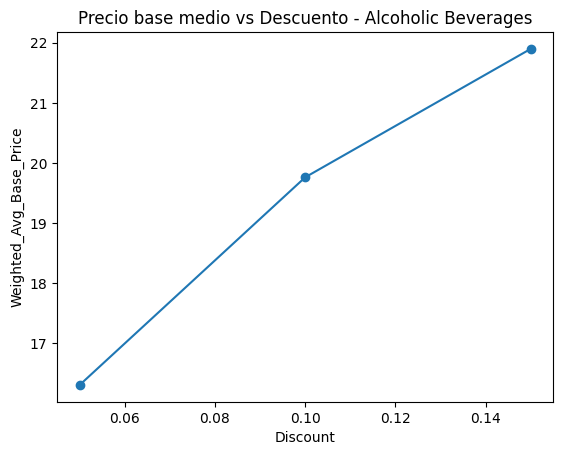

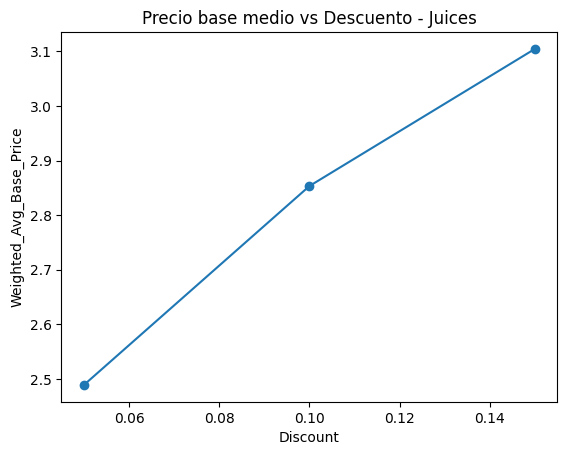

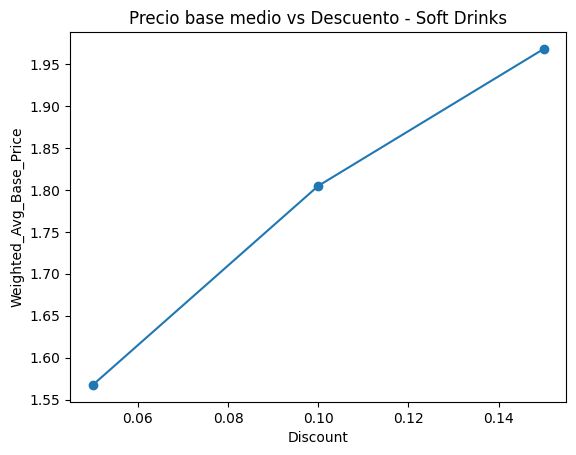

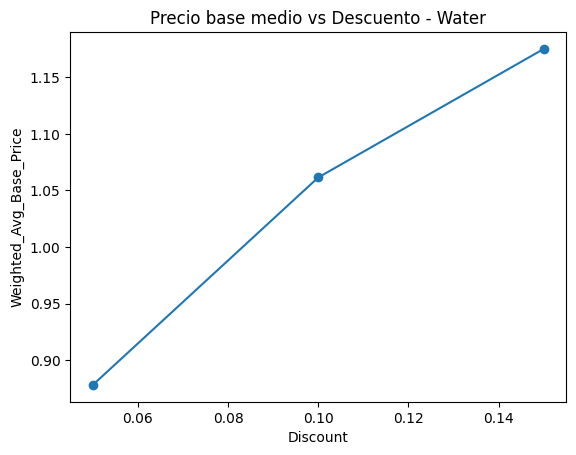

In [20]:
for cat in comparison['Category'].unique():
    subset = comparison[comparison['Category'] == cat]
    
    plt.figure()
    plt.plot(subset['Discount'], subset['Weighted_Avg_Base_Price'], marker='o')
    plt.title(f'Precio base medio vs Descuento - {cat}')
    plt.xlabel('Discount')
    plt.ylabel('Weighted_Avg_Base_Price')
    plt.show()

In [35]:
round(df['Product'].nunique()*0.2)
twenty_top_revenue=df.groupby('Product')['Total_Price'].sum().sort_values(ascending=False).head(9).reset_index(name='Revenue_per_Product')
twenty_top_revenue

,Product,Revenue_per_Product
0,Veuve Clicquot,2.025819e+08
1,Moët & Chandon,1.750881e+08
2,Johnnie Walker,9.726180e+07
3,Jack Daniels,9.588100e+07
4,Tanqueray,8.614366e+07
5,Bacardi,5.846750e+07
6,Havana Club,5.804696e+07
7,Sauvignon Blanc,2.331918e+07
8,Cranberry Juice,2.304483e+07


In [37]:
#Pareto de ingresos por producto

#Se calcula cuanto es el 20% de los productos para identificar el umbral del Pareto
df['Product'].nunique()*0.2

#El resultado es 9,4, es decir, lo redondeamos a 10 productos para identificar el top 10 que generan el 80% de los ingresos
#Agrupamos por producto y sumamos los ingresos totales, luego ordenamos de mayor a menor para identificar los productos más rentables y finalmente seleccionamos el top 10
twenty_top_revenue = (
    df.groupby('Product')['Total_Price']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index(name='Revenue_per_Product')
)

#Sumamos los ingresos generados por el top 10 de productos para calcular su contribución total
total_twenty_top_revenue = twenty_top_revenue['Revenue_per_Product'].sum()
#Calculamos el porcentaje que representa el ingreso del top 10 respecto al ingreso total de la empresa para obtener el Pareto
Pareto= round(total_twenty_top_revenue*100/df['Total_Price'].sum(),2)
print(f'El resultado es {Pareto}%')





El resultado es 71.6%


In [ ]:
#Principio de Pareto aplicado a clientes
#Se calcula el 20% de los clientes para identificar el umbral del Pareto
df['Customer_ID'].nunique()*0.2

#El resultado es 2000, es decir, lo redondeamos a 2000 clientes para identificar el top 2000 que generan el 80% de los ingresos
#Agrupamos por cliente y sumamos los ingresos totales, luego ordenamos de mayor a menor para identificar los clientes más rentables y finalmente seleccionamos el top 2000
twenty_top_customers= (
    df.groupby('Customer_ID')['Total_Price']
    .sum()
    .sort_values(ascending=False)
    .head(2000)
    .reset_index(name='Revenue_per_Customer')                                                                                       
)

#Sumamos los ingresos generados por el top 2000 de clientes para calcular su contribución total
total_twenty_top_customers_revenue=twenty_top_customers['Revenue_per_Customer'].sum()

#Calculamos el porcentaje que representa el ingreso del top 2000 respecto al ingreso total de la empresa para obtener el Pareto
Pareto_customers= round(total_twenty_top_customers_revenue*100/df['Total_Price'].sum(),2)
print(f'El resultado es {Pareto_customers}%')

El resultado es 46.53%


In [ ]:
#Agrupamos por región y contamos el número de pedidos únicos para identificar cuáles son las regiones con mayor actividad comercial, ordenamos de mayor a menor para obtener una visión clara de la distribución geográfica de los pedidos y finalmente reseteamos el índice para facilitar la lectura del resultado.
df.groupby('Region')['Order_ID'].nunique().sort_values(ascending=False).reset_index()



In [ ]:
#Agrupamos por región y sumamos el ingreso total para cada pedido
region_total=df.groupby(['Order_ID', 'Region'])['Total_Price'].sum().reset_index()

#Agrupamos por región y calculamos el ingreso promedio por pedido para cada región, ordenamos de mayor a menor para identificar las regiones con mayor ticket medio y finalmente reseteamos el índice para facilitar la lectura del resultado.
Avg_Region_Ticket=round(
   region_total.groupby('Region')['Total_Price']
    .mean().sort_values(ascending=False)
    .reset_index(name='Avg_Ticket'),2)
Avg_Region_Ticket


In [ ]:
#Agrupamos por región y producto, sumamos el ingreso total para cada combinación, ordenamos por región y luego por ingreso total de mayor a menor para identificar el producto más rentable en cada región, finalmente eliminamos los duplicados para quedarnos solo con el top producto por región.
top_product_revenue_Region = (
    df.groupby(['Region', 'Product'])['Total_Price']
      .sum()
      .reset_index()
      .sort_values(by=['Region', 'Total_Price'], ascending=[True, False])
      .drop_duplicates(subset='Region')
)
top_product_revenue_Region


In [ ]:
#Agrupamos por región y producto, contamos el número de pedidos únicos para cada combinación, ordenamos por región y luego por número de pedidos de mayor a menor para identificar el producto más vendido en cada región, finalmente eliminamos los duplicados para quedarnos solo con el top producto por región.
top_product_ORDER_Region = (
    df.groupby(['Region', 'Product'])['Order_ID']
      .nunique()
      .reset_index()
      .sort_values(by=['Region', 'Order_ID'], ascending=[True, False])
      .drop_duplicates(subset='Region')
)
top_product_ORDER_Region
